# Homework 5: Summarise + OCR On-Screen Text

Two final stages, both with [Qwen2.5-VL](https://huggingface.co/Qwen/Qwen2.5-VL-7B-Instruct):

1. **Summarise** the English translation (text-only chat).
2. **OCR** the on-screen text by sampling video frames at **1 fps** and reading
   each with the vision model, then deduplicating across frames.

**Sources**
- Qwen2.5-VL: <https://huggingface.co/Qwen/Qwen2.5-VL-7B-Instruct>
- OCR pipeline: `src/video_pipeline/ocr_pipeline.py` · `qwen-vl-utils`: <https://pypi.org/project/qwen-vl-utils/>

In [1]:
import json
import shutil
import subprocess
import sys
from pathlib import Path

# Make the vendored `video_pipeline` package importable even if the project
# was not installed (e.g. running `jupyter` outside `uv run`).
SRC = Path.cwd() / "src"
if SRC.exists() and str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

PREPARED = Path("prepared")
PREPARED.mkdir(exist_ok=True)

translation = json.loads((PREPARED / "translation.json").read_text(encoding="utf-8"))
english_text = translation["text"]
mp4_path = next(PREPARED.glob("*.mp4"))   # the clip you prepared in 00_PrepData
print("English transcript:", len(english_text), "chars")
print("video:", mp4_path, "exists:", mp4_path.exists())

English transcript: 1475 chars
video: prepared/coldwar.mp4 exists: True


## 1. Summarise the English transcript

`QwenChat.summarize(text, language)` asks the model for a faithful summary in the
requested language.

In [ ]:
from video_pipeline.qwen_text import QwenChat
from video_pipeline.models import SummaryResult

# TODONE (Exercise 3a): summarise `english_text`. What language is it in now? - english
with QwenChat() as qc:
    summary = qc.summarize(english_text, language="English")

summary_result = SummaryResult(
    source_path=str(PREPARED / "translation.json"),
    language="English", source_text=english_text, summary=summary,
)
(PREPARED / "summary.json").write_text(summary_result.model_dump_json(indent=2), encoding="utf-8")
print(summary)

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

/home/azureuser/localfiles/jonas_g/GAI4/HW_5/.venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/home/azureuser/localfiles/jonas_g/GAI4/HW_5/.venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


The Cold War, beginning after World War II in 1945, was a prolonged conflict between the United States and the Soviet Union characterized by threats and arms buildup rather than direct combat. This rivalry, spanning 45 years, involved ideological competition between communism and capitalism, as well as a race for global influence through military and technological advancements, including nuclear weapons and space exploration. The Cold War ended with the reunification of Germany and the dissolution of the Soviet Union in 1991. However, it resumed in 2022 with Russia's invasion of Ukraine.


## 2. OCR the on-screen text

`OCRPipeline.run(video, fps=1)` samples one frame per second with FFmpeg, runs
Qwen2.5-VL as an OCR engine on each, and deduplicates the detected text blocks.

> Equivalent on the command line:
> ```bash
> uv run video-pipeline ocr prepared/STEM.mp4 --fps 1 -o prepared/ocr.json
> ```

In [3]:
from video_pipeline.ocr_pipeline import OCRPipeline

# TODONE (Exercise 3b): OCR the video at one frame per second.
with OCRPipeline() as op:
    ocr = op.run(mp4_path, fps=1)

ocr_path = PREPARED / "ocr.json"
ocr_path.write_text(ocr.model_dump_json(indent=2), encoding="utf-8")
print(f"{ocr.frame_count} frames, {len(ocr.unique_text_blocks)} unique text blocks")

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

/home/azureuser/localfiles/jonas_g/GAI4/HW_5/.venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


100 frames, 31 unique text blocks


In [4]:
print("=== Unique on-screen text blocks ===")
for block in ocr.unique_text_blocks:
    print("-", block.replace("\n", " / "))

=== Unique on-screen text blocks ===
- WDR / Der Kalte Krieg
- WDR / Der Kalte Krieg / in 100 Sekunden
- WDR / Der Kalte Krieg / in 100 Sekunden / 1945
- WDR / 1945
- WDR
- WDR / INDOCHINA-ONE BIG FIREFI / JAIL: THE BRASS AND / THE BANKERS & BOSSES / NEW YORK LIBRARY GUILD / LOCAL 1930 / CENTER FOR UNITED LABOR ACTION
- WDR / INDOCHINA-ONE BIG PILE / JAIL THE BRASS AND / THE BANKERS & BOSSES / CENTER FOR UNITED LABOR ACTION / PEACE / NOW
- WDR / ENDOCHINA-ONE BIG MESS / JAIL THE BRASS AND / THE BANKERS & BOSSES / CENTER FOR UNITED LABOR ACTION / NEW YORK LIBRARY / LOCAL 19 / PEACE / NOW
- WDR / INDOCHINA-ONE BIG MYLAI / JAIL THE BRASS AND / THE BANKERS & BOSSES / CENTER FOR UNITED LABOR ACTION / PEACE / NOW
- WDR / INDOCHINA-ONE BIG PRISON / JAIL THE BRASS AND / THE BANKERS & BOSSES / CENTER FOR UNITED LABOR ACTION / NEW YORK LIBRARY / LOCAL 19 / PEACE / NOW
- WDR / 1949
- WDR / 1949 / DDR
- WDR / BRD / DDR / 1949
- WDR / BRD / DDR
- WDR / BRD / DDR / Да здравствует / ПЯТАЯ / ГОДОВЩИНА

## 3. Frames side by side with their OCR text

The three frames with the most (distinct) detected text, each shown next to what
Qwen2.5-VL read from it. The OCR pipeline deletes its frames after running, so we
re-sample the video at the same fps — the `frame_number` then lines up with the
OCR result.

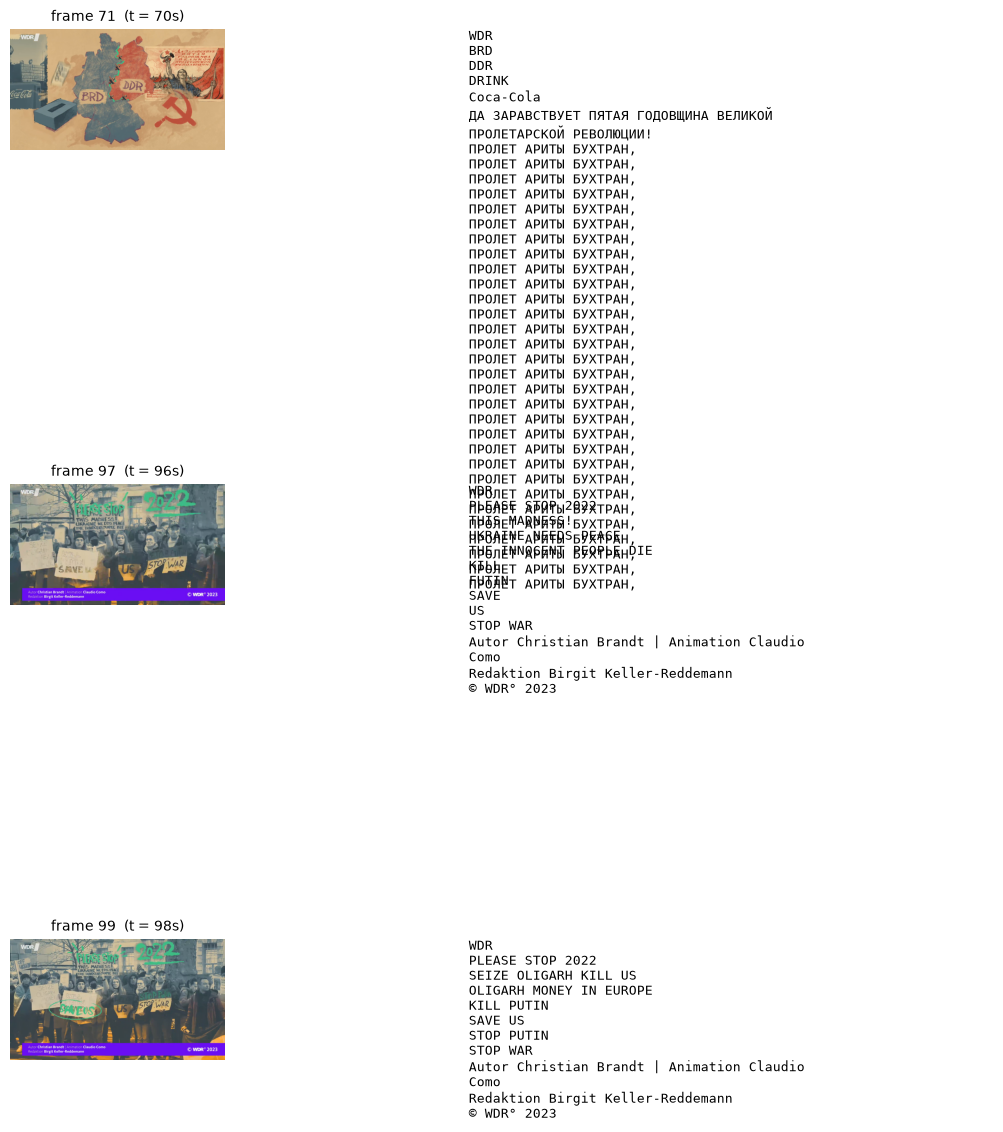

In [5]:
import tempfile, textwrap
import matplotlib.pyplot as plt
from PIL import Image
from video_pipeline.frame_extractor import extract_frames

# Re-sample frames at the same fps the OCR used so frame_number lines up.
tmp = Path(tempfile.mkdtemp(prefix="vp_show_"))
frames = extract_frames(mp4_path, fps=ocr.fps, output_dir=tmp)
by_number = {fr.frame_number: fr.path for fr in frames}

# Top 3 frames by amount of OCR text, skipping near-duplicate text so the
# panels show distinct on-screen content.
top, seen = [], set()
for f in sorted(ocr.frames, key=lambda fr: len(fr.text), reverse=True):
    key = " ".join(f.text.split()).lower()
    if not key or key in seen:
        continue
    seen.add(key)
    top.append(f)
    if len(top) == 3:
        break

fig, axes = plt.subplots(len(top), 2, figsize=(13, 3.6 * len(top)),
                         gridspec_kw={"width_ratios": [3, 2]})
axes = axes.reshape(len(top), 2)
for (ax_img, ax_txt), f in zip(axes, top):
    ax_img.imshow(Image.open(by_number[f.frame_number]).convert("RGB"))
    ax_img.set_title(f"frame {f.frame_number}  (t = {f.timestamp:.0f}s)", fontsize=10)
    ax_img.axis("off")
    ax_txt.axis("off")
    body = "\n".join(textwrap.fill(line, 46) for line in f.text.splitlines())
    ax_txt.text(0.0, 1.0, body, va="top", ha="left", family="monospace", fontsize=9)
plt.tight_layout()
plt.show()

shutil.rmtree(tmp, ignore_errors=True)

## Conclusion

You now have, under `prepared/`:

- `transcript.json` — German speech-to-text (Whisper)
- `translation.json` — English translation (Qwen2.5-VL)
- `summary.json` — English summary (Qwen2.5-VL)
- `ocr.json` — deduplicated on-screen text (Qwen2.5-VL)

### Deliverables (Homework 5)

1. The three notebooks (`00`, `01`, `02`) **executed end-to-end** and exported to
   **HTML**, on a Planet Wissen clip **of your choice**.
2. A short **report** (≤1 page): which clip you used, the English summary, and a
   brief comment on the OCR quality (what on-screen text was/wasn't captured).